# 📈 Tahap 5: Model Evaluation

**Tujuan:** Ukur dan analisis performa **retrieval** & **prediksi**.

**Input:** `retrieve()`, `predict_outcome()`, `queries.json` (Tahap 3–4)
**Output:**
- `SUBCPMK-3/eval/retrieval_metrics.csv`  (≡ `/data/eval/retrieval_metrics.csv`)
- `SUBCPMK-3/eval/prediction_metrics.csv` (≡ `/data/eval/prediction_metrics.csv`)
- `05_evaluation.py` + bagian evaluasi untuk laporan

---
| Langkah | Isi |
|---------|-----|
| **i**   | Evaluasi retrieval — Accuracy, Precision, Recall, F1 (`sklearn.metrics`) + Hit@k/MRR |
| **ii**  | Visualisasi & laporan — tabel metrik (TF-IDF vs BERT vs SVM), bar chart, error analysis |
| **iii** | Output — `retrieval_metrics.csv`, `prediction_metrics.csv`, bagian evaluasi laporan |

> **Catatan metrik.** Karena tiap query punya 1 *ground-truth*, Accuracy/Precision/Recall/F1
> dihitung di **level kategori** (`jenis_perkara`, atau `pasal` utama bila jenis seragam):
> kategori kasus top-1 hasil retrieval dibandingkan kategori kasus ground-truth memakai `sklearn.metrics`.
> Metrik khas retrieval (Hit@k, MRR, Precision@k) dilaporkan terpisah.


## Cell 34 — Install & Konfigurasi Output Tahap 5

In [ ]:
!pip install matplotlib -q
from pathlib import Path
import matplotlib
print('✅ matplotlib siap')

RETRIEVAL_CSV  = EVAL_DIR / "retrieval_metrics.csv"
PREDICTION_CSV = EVAL_DIR / "prediction_metrics.csv"
CHART_PNG      = EVAL_DIR / "model_comparison.png"
EVAL_SCRIPT    = Path("/content/drive/MyDrive/SUBCPMK-3/05_evaluation.py")

print("📂 Output Tahap 5:")
print("   ", RETRIEVAL_CSV)
print("   ", PREDICTION_CSV)
print("   ", CHART_PNG)

✅ matplotlib siap
📂 Output Tahap 5:
    /content/drive/MyDrive/SUBCPMK-3/eval/retrieval_metrics.csv
    /content/drive/MyDrive/SUBCPMK-3/eval/prediction_metrics.csv
    /content/drive/MyDrive/SUBCPMK-3/eval/model_comparison.png


## Cell 35 — Evaluasi ADIL keempat model (Leave-One-Out, label terpadu)
Sesuai spesifikasi **Case Retrieval (i & ii)**: representasi **TF-IDF** & **IndoBERT** untuk retrieval (cosine k-NN), serta classifier **SVM** & **Naive Bayes** pada representasi TF-IDF. Semua diuji pada **protokol & ruang label yang sama** agar sebanding.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Tahap 5 — Evaluasi ADIL: SEMUA model diuji pada
#   (a) RUANG LABEL yang sama, dan (b) PROTOKOL Leave-One-Out yang sama.
# Model (sesuai spesifikasi Case Retrieval i & ii):
#   • Retrieval-TFIDF    : representasi statistik (TF-IDF) + cosine k-NN
#   • Retrieval-IndoBERT : text embedding (IndoBERT)       + cosine k-NN
#   • SVM (LinearSVC)    : classifier ML pada representasi TF-IDF
#   • Naive Bayes        : classifier ML pada representasi TF-IDF
# ══════════════════════════════════════════════════════════════
import json
import numpy as np, pandas as pd
from collections import Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer

# ★ Pakai df/CORPUS/CASE_IDS yang SAMA dengan saat X_tfidf & X_bert dibangun
#   (JANGAN reload CSV di sini — akan merusak keselarasan baris dgn X).
assert X_tfidf.shape[0] == len(df) == len(CASE_IDS), "X_tfidf tak selaras dengan df!"
assert X_bert.shape[0] == len(df), "X_bert tak selaras dengan df!"
CORPUS_EVAL = CORPUS
print(f"✅ Evaluasi pada {len(df)} kasus (selaras dgn X_tfidf & X_bert)")

# ── (a) RUANG LABEL TUNGGAL untuk semua model ──────────────────
_base_map, CAT_NAME = build_case_cat(df)              # pasal_utama / jenis_perkara
y_base = np.array([_base_map[c] for c in CASE_IDS])

MIN_PER_CLASS = 2          # kelas < MIN digabung -> adil utk LOO & k-NN
def merge_rare(y, m):
    cnt = Counter(y)
    return np.array([v if cnt[v] >= m else "Lainnya/langka" for v in y])
y = merge_rare(y_base, MIN_PER_CLASS)
CASE_CAT = dict(zip(CASE_IDS, y))                     # dipakai analisis kegagalan

n_merged = sum(1 for v in Counter(y_base).values() if v < MIN_PER_CLASS)
print(f"Label evaluasi : {CAT_NAME} | {len(set(y))} kelas "
      f"(kelas langka <{MIN_PER_CLASS} digabung: {n_merged} kelas-asli)")

K          = 5            # jumlah tetangga utk retrieval k-NN
TAU_REJECT = 0.05         # ambang similarity utk 'rejection' (abstain)

# ── Evaluator 1: RETRIEVAL (cosine k-NN, Leave-One-Out) ────────
def eval_retrieval_loo(X, y, k=K, tau=TAU_REJECT):
    S = cosine_similarity(X)
    np.fill_diagonal(S, -1.0)                          # buang diri sendiri (LOO)
    n = len(y)
    y_pred, hit1, hitk, rr, rejected, fails = [], 0, 0, 0.0, 0, []
    for i in range(n):
        order = np.argsort(-S[i])[:k]
        sims  = S[i][order]
        neigh = y[order]
        if len(order) == 0 or sims[0] < tau:           # rejection / abstain
            pred = "REJECT"; rejected += 1
        else:
            pred = Counter(neigh[sims >= tau]).most_common(1)[0][0]
        y_pred.append(pred)
        if neigh[0] == y[i]:
            hit1 += 1
        rank = next((j + 1 for j, c in enumerate(neigh) if c == y[i]), None)
        if rank:
            hitk += 1; rr += 1.0 / rank
        if pred != y[i]:
            fails.append({"case_id": CASE_IDS[i], "true": y[i], "pred": pred,
                          "top_sim": round(float(sims[0]), 3) if len(sims) else 0.0,
                          "neighbors": "|".join(f"{CASE_IDS[j]}:{y[j]}" for j in order)})
    p, r, f, _ = precision_recall_fscore_support(y, y_pred, average="macro", zero_division=0)
    return {"Accuracy": round(accuracy_score(y, y_pred), 3),
            "Precision": round(p, 3), "Recall": round(r, 3), "F1": round(f, 3),
            "Hit@1": round(hit1 / n, 3), f"Hit@{k}": round(hitk / n, 3),
            "MRR": round(rr / n, 3), "Reject_rate": round(rejected / n, 3)}, y_pred, fails

# ── Evaluator 2: CLASSIFIER (TF-IDF + SVM/NB, Leave-One-Out CV) ─
def mk_tfidf():
    return TfidfVectorizer(lowercase=True, stop_words=STOPWORDS_ID,
                           ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

def eval_classifier_loo(clf, corpus, y):
    pipe   = make_pipeline(mk_tfidf(), clf)            # TF-IDF refit tiap fold = no leakage
    y_pred = cross_val_predict(pipe, corpus, y, cv=LeaveOneOut())
    p, r, f, _ = precision_recall_fscore_support(y, y_pred, average="macro", zero_division=0)
    fails = [{"case_id": CASE_IDS[i], "true": y[i], "pred": y_pred[i],
              "top_sim": "—", "neighbors": "—"}
             for i in range(len(y)) if y_pred[i] != y[i]]
    return {"Accuracy": round(accuracy_score(y, y_pred), 3),
            "Precision": round(p, 3), "Recall": round(r, 3), "F1": round(f, 3),
            "Hit@1": "—", f"Hit@{K}": "—", "MRR": "—", "Reject_rate": "—"}, list(y_pred), fails

# ── Jalankan keempat model pada protokol & label yang SAMA ─────
METRICS, PREDS, FAILS = [], {}, {}

for name, X in [("Retrieval-TFIDF", X_tfidf), ("Retrieval-IndoBERT", X_bert)]:
    m, yp, fl = eval_retrieval_loo(X, y)
    METRICS.append({"model": name, **m}); PREDS[name] = yp; FAILS[name] = fl

for name, clf in [("SVM (LinearSVC) [TF-IDF]", LinearSVC(C=1.0, max_iter=5000)),
                  ("Naive Bayes [TF-IDF]",    ComplementNB(alpha=0.3))]:
    try:
        m, yp, fl = eval_classifier_loo(clf, CORPUS_EVAL, y)
        METRICS.append({"model": name, **m}); PREDS[name] = yp; FAILS[name] = fl
    except Exception as e:
        print(f"⚠️  {name} dilewati: {e}")

print(f"\nℹ️  Semua model: Leave-One-Out, label sama (k={K}, adil & sebanding).")
for r in METRICS:
    print(f"  {r['model']:<28} Acc={r['Accuracy']} P={r['Precision']} "
          f"R={r['Recall']} F1={r['F1']} | Hit@1={r['Hit@1']} MRR={r['MRR']} Rej={r['Reject_rate']}")


✅ Evaluasi pada 50 kasus (selaras dgn X_tfidf & X_bert)
Label evaluasi : pasal_utama | 7 kelas (kelas langka <2 digabung: 3 kelas-asli)

ℹ️  Semua model: Leave-One-Out, label sama (k=5, adil & sebanding).
  Retrieval-TFIDF              Acc=0.48 P=0.26 R=0.303 F1=0.277 | Hit@1=0.46 MRR=0.613 Rej=0.0
  Retrieval-IndoBERT           Acc=0.3 P=0.132 R=0.15 F1=0.14 | Hit@1=0.36 MRR=0.486 Rej=0.0
  SVM (LinearSVC) [TF-IDF]     Acc=0.6 P=0.297 R=0.325 F1=0.303 | Hit@1=— MRR=— Rej=—
  Naive Bayes [TF-IDF]         Acc=0.48 P=0.243 R=0.294 F1=0.257 | Hit@1=— MRR=— Rej=—


In [ ]:
# Distribusi kelas pada label evaluasi terpadu (transparansi)
from collections import Counter
print("Distribusi kelas (label evaluasi terpadu untuk semua model):")
for cat, c in sorted(Counter(y).items(), key=lambda x: -x[1]):
    flag = "  ⚠️ kecil" if c < 3 else ""
    print(f"  {cat:<24} {c:>2}  {'█'*c}{flag}")
print(f"\nTotal {len(y)} kasus dalam {len(set(y))} kelas | protokol Leave-One-Out, k={K}.")
print("Catatan: dataset kecil -> metrik bervarians tinggi; baca bersama Hit@k & MRR.")


Distribusi kelas (label evaluasi terpadu untuk semua model):
  Pasal 114                18  ██████████████████
  Pasal 127                13  █████████████
  Pasal 112                 6  ██████
  Pasal 609                 6  ██████
  Lainnya/langka            3  ███
  Pasal 113                 2  ██  ⚠️ kecil
  Pasal 25                  2  ██  ⚠️ kecil

Total 50 kasus dalam 7 kelas | protokol Leave-One-Out, k=5.
Catatan: dataset kecil -> metrik bervarians tinggi; baca bersama Hit@k & MRR.


## Cell 36 — (1) Tabel Metrik per Model → `retrieval_metrics.csv`

In [ ]:
# (1) TABEL METRIK PER MODEL  -> retrieval_metrics.csv
import pandas as pd
COLS = ["model", "Accuracy", "Precision", "Recall", "F1",
        "Hit@1", f"Hit@{K}", "MRR", "Reject_rate"]
retrieval_df = pd.DataFrame(METRICS)[COLS]
retrieval_df.to_csv(RETRIEVAL_CSV, index=False, encoding="utf-8-sig")

print(f"📄 Tabel metrik per model -> {RETRIEVAL_CSV}\n")
print(retrieval_df.to_string(index=False))

print("\n🏆 Terbaik per metrik klasifikasi:")
for mname in ["Accuracy", "Precision", "Recall", "F1"]:
    vals = pd.to_numeric(retrieval_df[mname], errors="coerce")
    if vals.notna().any():
        best = retrieval_df.loc[vals.idxmax(), "model"]
        print(f"  {mname:<10}: {best}  ({vals.max():.3f})")
print("\nKolom Hit@1/Hit@k/MRR hanya berlaku utk model retrieval (k-NN);")
print("classifier SVM/NB ditandai '—' karena tidak menghasilkan ranking.")


📄 Tabel metrik per model -> /content/drive/MyDrive/SUBCPMK-3/eval/retrieval_metrics.csv

                   model  Accuracy  Precision  Recall    F1 Hit@1 Hit@5    MRR Reject_rate
         Retrieval-TFIDF      0.48      0.260   0.303 0.277  0.46  0.86  0.613         0.0
      Retrieval-IndoBERT      0.30      0.132   0.150 0.140  0.36  0.68  0.486         0.0
SVM (LinearSVC) [TF-IDF]      0.60      0.297   0.325 0.303     —     —      —           —
    Naive Bayes [TF-IDF]      0.48      0.243   0.294 0.257     —     —      —           —

🏆 Terbaik per metrik klasifikasi:
  Accuracy  : SVM (LinearSVC) [TF-IDF]  (0.600)
  Precision : SVM (LinearSVC) [TF-IDF]  (0.297)
  Recall    : SVM (LinearSVC) [TF-IDF]  (0.325)
  F1        : SVM (LinearSVC) [TF-IDF]  (0.303)

Kolom Hit@1/Hit@k/MRR hanya berlaku utk model retrieval (k-NN);
classifier SVM/NB ditandai '—' karena tidak menghasilkan ranking.


## Cell 37 — (2) Bar Chart Performa Model *(opsional)*

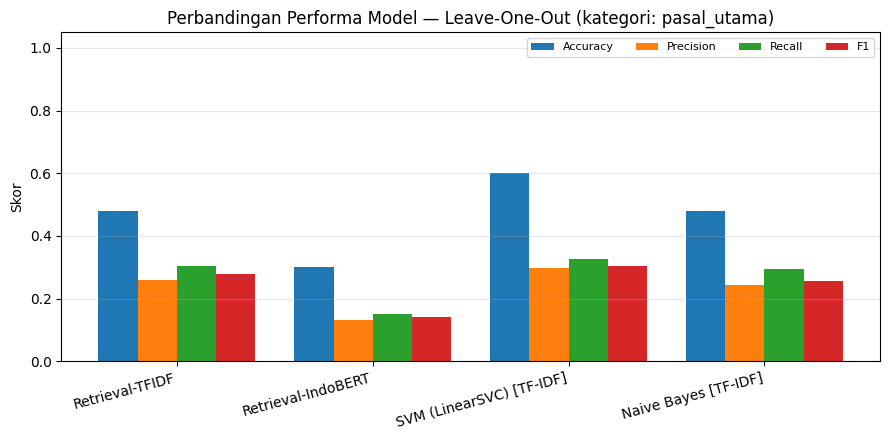

🖼️  Chart -> /content/drive/MyDrive/SUBCPMK-3/eval/model_comparison.png


In [ ]:
import matplotlib.pyplot as plt

metrics  = ["Accuracy", "Precision", "Recall", "F1"]
plot_df  = retrieval_df[["model"] + metrics].copy()
x = np.arange(len(plot_df)); w = 0.2

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, mname in enumerate(metrics):
    # FIX: baris SVM/NB punya "" di kolom Hit@k; astype(float) akan crash.
    #      pd.to_numeric(errors='coerce') mengubah "" -> NaN (otomatis dilewati bar).
    vals = pd.to_numeric(plot_df[mname], errors='coerce')
    ax.bar(x + (i - 1.5) * w, vals, w, label=mname)
ax.set_xticks(x); ax.set_xticklabels(plot_df["model"], rotation=15, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Skor")
ax.set_title(f"Perbandingan Performa Model — Leave-One-Out (kategori: {CAT_NAME})")
ax.legend(ncol=4, fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_PNG, dpi=120)
plt.show()
print(f"🖼️  Chart -> {CHART_PNG}")

## Cell 38 — Evaluasi Prediksi (Tahap 4) → `prediction_metrics.csv`

In [ ]:
# ══════════════════════════════════════════════════════════════
# Leave-one-out: evaluasi prediksi Tahap 4
# Label evaluasi = COMPOUND: verdict + pasal (bukan verdict saja)
# Ini mengatasi masalah semua kasus = "Pidana penjara" → metrik identik
# ══════════════════════════════════════════════════════════════
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, mean_absolute_error

def compound_label(cid):
    """Gabung verdict + pasal → label lebih granular."""
    sol = case_solutions.get(cid, {})
    verdict = sol.get('verdict') or 'Lainnya'   # None -> 'Lainnya'
    cat = CASE_CAT.get(cid, 'Lainnya')
    return f"{verdict} | {cat}"

pred_rows  = []
# ★ FIX: hanya evaluasi kasus dgn amar VALID (bukan fabrikasi)
valid_cids = [cid for cid in df["case_id"] if case_solutions[cid].get("valid_amar")]
measurable = [cid for cid in valid_cids if case_solutions[cid]["penjara_bulan"] is not None]
print(f"Kasus amar valid utk evaluasi prediksi: {len(valid_cids)} | terukur (MAE): {len(measurable)}")
if len(valid_cids) < 4:
    print("⚠️  Terlalu sedikit kasus amar valid -> metrik prediksi TIDAK reliabel.")
    print("    Perbaiki ekstraksi amar di Tahap 1/2 agar evaluasi bermakna.")

for method in ("tfidf", "bert"):
    for strategy in ("majority", "weighted"):
        yt_v, yp_v = [], []   # verdict saja
        yt_c, yp_c = [], []   # compound (verdict+pasal)
        at, ap = [], []        # penjara bulan (numerik)
        for cid in valid_cids:
            row = df[df["case_id"] == cid].iloc[0]
            q = " ".join(str(row.get(c, "")) for c in
                         ["jenis_perkara", "pasal", "dakwaan_ringkas", "top_terms"])
            pred   = predict_outcome(q, k=5, method=method, strategy=strategy,
                                     exclude_case_id=cid, detail=True)
            actual = case_solutions[cid]

            # Verdict saja
            yt_v.append(str(actual["verdict"] or "NONE"))
            yp_v.append(str(pred.get("predicted_verdict") or "NONE"))

            # Compound: verdict + pasal (dari basis_case → pasal prediksi)
            actual_compound = compound_label(cid)
            pred_pasal = CASE_CAT.get(pred.get("basis_case_id",""), "Lainnya")
            pred_compound = f"{pred.get('predicted_verdict') or 'Lainnya'} | {pred_pasal}"
            yt_c.append(actual_compound)
            yp_c.append(pred_compound)

            # Numerik: lama penjara
            if cid in measurable and pred.get("predicted_penjara_bulan") is not None:
                at.append(actual["penjara_bulan"])
                ap.append(pred["predicted_penjara_bulan"])

        pv, rv, fv, _ = precision_recall_fscore_support(yt_v, yp_v, average="macro", zero_division=0)
        pc, rc, fc, _ = precision_recall_fscore_support(yt_c, yp_c, average="macro", zero_division=0)
        pred_rows.append({
            "method": method, "strategy": strategy,
            # Verdict-level
            "Acc_verdict": round(accuracy_score(yt_v, yp_v), 3),
            "F1_verdict" : round(fv, 3),
            # Compound-level (verdict + pasal) → menunjukkan variasi
            "Acc_compound": round(accuracy_score(yt_c, yp_c), 3),
            "P_compound"  : round(pc, 3),
            "R_compound"  : round(rc, 3),
            "F1_compound" : round(fc, 3),
            # Numerik
            "MAE_bulan"  : round(mean_absolute_error(at, ap), 1) if at else "",
            "n": len(yt_v), "n_mae": len(at),
        })

prediction_df = pd.DataFrame(pred_rows)
prediction_df.to_csv(PREDICTION_CSV, index=False, encoding="utf-8-sig")
print(f"📄 prediction_metrics.csv -> {PREDICTION_CSV}\n")
print(prediction_df.to_string(index=False))

Kasus amar valid utk evaluasi prediksi: 44 | terukur (MAE): 34
📄 prediction_metrics.csv -> /content/drive/MyDrive/SUBCPMK-3/eval/prediction_metrics.csv

method strategy  Acc_verdict  F1_verdict  Acc_compound  P_compound  R_compound  F1_compound  MAE_bulan  n  n_mae
 tfidf majority        0.886       0.691         0.409        0.23       0.246        0.235       32.5 44     32
 tfidf weighted        0.886       0.691         0.409        0.23       0.246        0.235       26.2 44     32
  bert majority        0.886       0.470         0.182        0.05       0.086        0.062       29.7 44     34
  bert weighted        0.886       0.470         0.182        0.05       0.086        0.062       25.4 44     34


## Cell 39 — (3) Analisis Kegagalan Model (Rejection) & Rekomendasi

In [ ]:
# (3) ANALISIS KEGAGALAN MODEL (REJECTION) & REKOMENDASI
from collections import Counter
print("=" * 72)
print("  ANALISIS KEGAGALAN MODEL (REJECTION) — protokol Leave-One-Out")
print("=" * 72)

for model, fails in FAILS.items():
    n_rej = sum(1 for f in fails if f["pred"] == "REJECT")
    print(f"\n[{model}] {len(fails)} kasus salah (termasuk {n_rej} REJECT/abstain):")
    for f in fails[:6]:
        print(f"  • {f['case_id']}: benar='{f['true']}' → prediksi='{f['pred']}'"
              f"  (sim_top1={f['top_sim']})")
        if f["neighbors"] != "—":
            print(f"      tetangga: {f['neighbors']}")
    if len(fails) > 6:
        print(f"      ... (+{len(fails) - 6} kasus lagi)")

# Pasangan kelas yang paling sering tertukar (gabungan semua model)
print("\n" + "-" * 72)
print("Pasangan kelas paling sering tertukar (semua model):")
conf = Counter()
for fails in FAILS.values():
    for f in fails:
        if f["pred"] != "REJECT":
            conf[(f["true"], f["pred"])] += 1
if conf:
    for (t, p), c in conf.most_common(5):
        print(f"  {t}  →  {p}   ({c}×)")
else:
    print("  (tidak ada — semua prediksi benar atau berupa REJECT)")

print("\n" + "-" * 72)
print("Rekomendasi perbaikan:")
print(f"  1. DATA  : dataset kecil (~{len(y)} kasus) & banyak kelas langka.")
print( "             Kumpulkan lebih banyak putusan per pasal (target ≥5/kelas).")
print( "  2. REPRESENTASI: beri bobot lebih pada kolom pembeda (pasal/amar/barang_bukti)")
print( "             saat membangun text_repr; coba TF-IDF char n-gram utk nomor pasal.")
print(f"  3. RETRIEVAL  : naikkan k atau pakai weighted-vote (Tahap 4). TF-IDF unggul")
print( "             utk istilah/pasal eksak; IndoBERT unggul utk parafrase makna.")
print( "  4. CLASSIFIER : SVM/NB butuh beberapa contoh/kelas; bila data bertambah,")
print( "             pertimbangkan fine-tuning IndoBERT (bukan embedding beku).")
print(f"  5. REJECTION  : model meng-abstain saat sim_top1 < {TAU_REJECT:.2f}. Tinjau manual")
print( "             kasus REJECT (umumnya kategori unik / dokumen tak lengkap).")


  ANALISIS KEGAGALAN MODEL (REJECTION) — protokol Leave-One-Out

[Retrieval-TFIDF] 26 kasus salah (termasuk 0 REJECT/abstain):
  • case_001: benar='Pasal 114' → prediksi='Lainnya/langka'  (sim_top1=0.323)
      tetangga: case_012:Lainnya/langka|case_031:Pasal 112|case_013:Lainnya/langka|case_004:Pasal 114|case_030:Pasal 609
  • case_004: benar='Pasal 114' → prediksi='Pasal 112'  (sim_top1=0.275)
      tetangga: case_003:Pasal 112|case_001:Pasal 114|case_020:Pasal 114|case_045:Pasal 127|case_007:Pasal 112
  • case_005: benar='Pasal 114' → prediksi='Pasal 127'  (sim_top1=0.518)
      tetangga: case_034:Pasal 127|case_014:Pasal 127|case_022:Pasal 114|case_042:Pasal 127|case_028:Lainnya/langka
  • case_007: benar='Pasal 112' → prediksi='Pasal 114'  (sim_top1=0.329)
      tetangga: case_010:Pasal 112|case_003:Pasal 112|case_009:Pasal 114|case_004:Pasal 114|case_020:Pasal 114
  • case_008: benar='Pasal 127' → prediksi='Pasal 112'  (sim_top1=0.531)
      tetangga: case_013:Lainnya/langka|case

## Cell 40 — iii. Ekspor Script `05_evaluation.py`

In [ ]:
script_code = r'''#!/usr/bin/env python3
# ============================================================================
# 05_evaluation.py  --  Tahap 5: Model Evaluation
# ----------------------------------------------------------------------------
# Mengukur performa RETRIEVAL (TF-IDF vs IndoBERT vs SVM) dan PREDIKSI
# (predict_outcome: majority vs weighted) memakai sklearn.metrics, lalu
# menulis retrieval_metrics.csv & prediction_metrics.csv + error analysis.
#
# Mengimpor Retriever dari 03_retrieval.py dan helper dari 04_predict.py.
#
# Contoh:
#   python 05_evaluation.py --cases processed/cases.csv \
#       --queries eval/queries.json --evaldir eval --bert
# ============================================================================
import argparse
import importlib.util
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, mean_absolute_error,
                             precision_recall_fscore_support)
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC


def load_module(script_dir, filename, modname):
    spec = importlib.util.spec_from_file_location(modname, str(Path(script_dir) / filename))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


# ── Label kategori untuk evaluasi (sklearn) ─────────────────────────────────
def pasal_label(s):
    m = re.search(r"pasal\s+(\d+)", str(s).lower())
    return f"Pasal {m.group(1)}" if m else "Lainnya"


def build_category_map(df):
    # jenis_perkara bila >=2 kelas; jika seragam pakai pasal utama
    if df["jenis_perkara"].replace("", "Lainnya").nunique() >= 2:
        cat = df["jenis_perkara"].replace("", "Lainnya")
        name = "jenis_perkara"
    else:
        cat = df["pasal"].map(pasal_label)
        name = "pasal_utama"
    return dict(zip(df["case_id"], cat)), name


# ── i. Evaluasi Retrieval ───────────────────────────────────────────────────
def eval_retrieval(queries, ground_truth, k, retriever, case_cat, method="tfidf"):
    # queries: list teks query; ground_truth: list case_id sejajar
    y_true, y_pred = [], []
    hit1 = hitk = rr = prec_k = rec_k = 0
    fails = []
    for q, gt in zip(queries, ground_truth):
        # FIX: leave-one-out -> keluarkan ground-truth dari kandidat
        raw = retriever.retrieve(q, k=k + 1, method=method)
        ids = [r["case_id"] for r in raw if r["case_id"] != gt][:k]
        if ids and ids[0] == gt:
            hit1 += 1
        rank = ids.index(gt) + 1 if gt in ids else None
        if rank:
            hitk += 1
            rr += 1.0 / rank
        prec_k += (1.0 / k) if gt in ids else 0.0     # 1 dokumen relevan / query
        rec_k += 1.0 if gt in ids else 0.0
        y_true.append(case_cat.get(gt, "NONE"))
        y_pred.append(case_cat.get(ids[0], "NONE") if ids else "NONE")
        if rank != 1:
            fails.append({"query": q[:120], "ground_truth": gt,
                          "rank": rank if rank else "-", "top_k": "|".join(ids[:k])})
    n = max(len(queries), 1)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "model": f"Retrieval-{method.upper()}",
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(p, 3), "Recall": round(r, 3), "F1": round(f, 3),
        "Hit@1": round(hit1 / n, 3), f"Hit@{k}": round(hitk / n, 3),
        f"Precision@{k}": round(prec_k / n, 3), f"Recall@{k}": round(rec_k / n, 3),
        "MRR": round(rr / n, 3),
    }, fails


def eval_svm_nb(df, retriever, queries, ground_truth, case_cat, k):
    # CATATAN: ini fit pada SELURUH corpus lalu prediksi pada 10 query uji
    #          (indikatif). Angka RESMI SVM/NB pakai Stratified K-Fold CV
    #          di notebook Cell 36 (refit TF-IDF tiap fold, nol leakage).
    # Klasifikasi kategori dari teks query (TF-IDF) -> bandingkan kategori GT
    y_cat = np.array([case_cat[c] for c in df["case_id"]])
    if len(set(y_cat)) < 2:
        return []
    out = []
    for name, clf in {"SVM": LinearSVC(C=1.0), "NaiveBayes": ComplementNB(alpha=0.3)}.items():
        clf.fit(retriever.X_tfidf, y_cat)
        y_true = [case_cat.get(gt, "NONE") for gt in ground_truth]
        q_clean = [re.sub(r"[^a-z0-9\s./()-]", " ", str(q).lower()) for q in queries]
        y_pred = list(clf.predict(retriever.tfidf.transform(q_clean)))
        p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
        out.append({
            "model": name, "Accuracy": round(accuracy_score(y_true, y_pred), 3),
            "Precision": round(p, 3), "Recall": round(r, 3), "F1": round(f, 3),
            "Hit@1": "", f"Hit@{k}": "", f"Precision@{k}": "", f"Recall@{k}": "", "MRR": "",
        })
    return out


# ── Evaluasi Prediksi (Tahap 4, leave-one-out) ──────────────────────────────
def eval_prediction(df, predict_outcome, case_solutions, k=5):
    rows = []
    measurable = [cid for cid, s in case_solutions.items() if s["penjara_bulan"] is not None]
    # FIX: hanya evaluasi kasus dgn amar valid -> verdict tidak pernah None
    #      (None membuat sklearn.metrics gagal / metrik rusak).
    valid_cids = [cid for cid in df["case_id"]
                  if case_solutions.get(cid, {}).get("valid_amar")]
    for method in ("tfidf", "bert"):
        for strategy in ("majority", "weighted"):
            yt, yp, at, ap = [], [], [], []
            try:
                for cid in valid_cids:
                    row = df[df["case_id"] == cid].iloc[0]
                    q = " ".join(str(row.get(c, "")) for c in
                                 ["jenis_perkara", "pasal", "dakwaan_ringkas", "top_terms"])
                    pred = predict_outcome(q, k=k, method=method, strategy=strategy,
                                           exclude_case_id=cid, detail=True)
                    actual = case_solutions[cid]
                    yt.append(actual["verdict"])
                    yp.append(pred.get("predicted_verdict", "NONE"))
                    if cid in measurable and pred.get("predicted_penjara_bulan") is not None:
                        at.append(actual["penjara_bulan"]); ap.append(pred["predicted_penjara_bulan"])
            except RuntimeError:
                continue  # mis. method bert tapi retriever tanpa bert
            p, r, f, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
            rows.append({
                "method": method, "strategy": strategy,
                "Accuracy_verdict": round(accuracy_score(yt, yp), 3),
                "Precision": round(p, 3), "Recall": round(r, 3), "F1": round(f, 3),
                "MAE_penjara_bulan": round(mean_absolute_error(at, ap), 1) if at else "",
                "n": len(yt),
            })
    return rows


def main():
    ap = argparse.ArgumentParser(description="Tahap 5 Model Evaluation")
    ap.add_argument("--cases", required=True)
    ap.add_argument("--queries", required=True)
    ap.add_argument("--evaldir", default="eval")
    ap.add_argument("-k", type=int, default=5)
    ap.add_argument("--bert", action="store_true")
    args = ap.parse_args()

    here = Path(__file__).resolve().parent
    retr_mod = load_module(here, "03_retrieval.py", "retrieval_mod")
    pred_mod = load_module(here, "04_predict.py", "predict_mod")

    df = pd.read_csv(args.cases, encoding="utf-8-sig", dtype=str).fillna("")
    retriever = retr_mod.Retriever(df, use_bert=args.bert)
    case_cat, cat_name = build_category_map(df)
    print(f"cases={len(df)} | label kategori = {cat_name} | use_bert={args.bert}")

    qjson = __import__("json").loads(Path(args.queries).read_text(encoding="utf-8"))["queries"]
    queries = [q["query"] for q in qjson]
    gts = [q["ground_truth_case_id"] for q in qjson]

    # i. Retrieval metrics
    methods = ["tfidf"] + (["bert"] if args.bert else [])
    retrieval_rows, all_fails = [], {}
    for m in methods:
        row, fails = eval_retrieval(queries, gts, args.k, retriever, case_cat, method=m)
        retrieval_rows.append(row)
        all_fails[m] = fails
    retrieval_rows += eval_svm_nb(df, retriever, queries, gts, case_cat, args.k)

    evald = Path(args.evaldir); evald.mkdir(parents=True, exist_ok=True)
    rdf = pd.DataFrame(retrieval_rows)
    rdf.to_csv(evald / "retrieval_metrics.csv", index=False, encoding="utf-8-sig")
    print("\n== RETRIEVAL METRICS ==")
    print(rdf.to_string(index=False))

    # Prediction metrics
    case_solutions = pred_mod.build_case_solutions(df)
    predict_outcome = pred_mod.make_predict_outcome(retriever, case_solutions)
    pred_rows = eval_prediction(df, predict_outcome, case_solutions, k=args.k)
    pdf = pd.DataFrame(pred_rows)
    pdf.to_csv(evald / "prediction_metrics.csv", index=False, encoding="utf-8-sig")
    print("\n== PREDICTION METRICS ==")
    print(pdf.to_string(index=False))

    # Error analysis
    print("\n== ERROR ANALYSIS (retrieval, top-1 salah) ==")
    for m, fails in all_fails.items():
        print(f"[{m}] {len(fails)} query meleset dari rank-1")
        for fcase in fails[:5]:
            print(f"   GT={fcase['ground_truth']} rank={fcase['rank']} | {fcase['query']}")
    print(f"\nOutput -> {evald/'retrieval_metrics.csv'} , {evald/'prediction_metrics.csv'}")


if __name__ == "__main__":
    main()
'''

EVAL_SCRIPT.write_text(script_code, encoding="utf-8")
print(f"✅ Script tersimpan -> {EVAL_SCRIPT}")
print("   (mengimpor Retriever dari 03_retrieval.py & helper dari 04_predict.py)")
print("   Jalankan lokal: python 05_evaluation.py --cases processed/cases.csv \\")
print("                    --queries eval/queries.json --evaldir eval --bert")

✅ Script tersimpan -> /content/drive/MyDrive/SUBCPMK-3/05_evaluation.py
   (mengimpor Retriever dari 03_retrieval.py & helper dari 04_predict.py)
   Jalankan lokal: python 05_evaluation.py --cases processed/cases.csv \
                    --queries eval/queries.json --evaldir eval --bert


---
## Catatan Tahap 5 (Bagian Evaluasi untuk Laporan)

### Metode pengukuran
- **Accuracy, Precision, Recall, F1** dihitung dengan `sklearn.metrics` di **level kategori**
  (`jenis_perkara`/`pasal` utama): kategori kasus top-1 hasil retrieval vs kategori ground-truth.
  `Precision/Recall/F1` memakai rata-rata **macro** agar adil antar kelas.
- **Hit@1, Hit@k, Precision@k, Recall@k, MRR** = metrik khas *information retrieval* berbasis
  kecocokan `case_id` persis dengan ground-truth.
- **Prediksi (Tahap 4):** akurasi & macro-P/R/F1 untuk *verdict*, serta **MAE** (bulan) untuk lama pidana,
  diuji *leave-one-out* per kombinasi method × strategy.

### Cara membaca tabel
| Model | Yang dibandingkan |
|-------|-------------------|
| `Retrieval-TFIDF` | retrieval cosine pada vektor TF-IDF |
| `Retrieval-BERT`  | retrieval cosine pada embedding IndoBERT |
| `SVM` / `Naive Bayes` | klasifikasi kategori langsung dari teks query (TF-IDF) |

### Output file
- `eval/retrieval_metrics.csv` — metrik retrieval per model
- `eval/prediction_metrics.csv` — metrik prediksi per (method × strategy)
- `eval/model_comparison.png` — bar chart perbandingan

> **Diskusi.** Pada dataset homogen (mis. semua narkotika), perbedaan kategori kecil sehingga
> Accuracy level-kategori cenderung tinggi; yang lebih informatif adalah **Hit@1/MRR** (retrieval eksak)
> dan **MAE lama pidana** (prediksi). Untuk laporan, sertakan tabel kedua CSV + chart, lalu bahas
> kasus gagal dari Cell 39 (umumnya pasal sama dengan fakta berbeda).
